## Load functions

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import time

In [2]:
def Marchenko_Pastur_significance_threshold(lam,var):
    sqrt = np.sqrt(lam)
    out1 = var*(1-sqrt)**2
    out2 = var*(1+sqrt)**2
    return (out1,out2)
    
def Marchenko_Pastur_distribution(lambda_min,lambda_max,lam,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(lam*x_vector)
    return x_vector,pdf

In [3]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.png'),format='png',dpi=200)
    plt.show()  

    return

In [4]:
from numba import njit

@njit
def species_growth_rates(R_vec,n_vec,
                 growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                ):
    ''' Growth of the species as a function of the resource abundances: g_i^\alpha(\vec{R},\vec{n})
    By default, we use nR/(1+R) on all resources.
    '''
    R_part = R_vec/(1+R_vec)
    outer = np.outer(R_part,n_vec) #Shape (N_R,N_n)
    outer = outer*growth_choices
    
    # if np.random.random()<1e-3:
    #     print('growth_rates',np.sum(outer>1e-3))
    #     print(outer[0,:])

    ''' Calculate also the total species growth rates '''
    species_total_growth_rate = np.sum(outer,axis=0) #shape (N_species)
    return outer,species_total_growth_rate

@njit
def resource_depletion_production(R_vec,n_vec,
                   total_species_growth_rate, #Shape (N_species)
                                  inv_yields):

    '''
    Calculates g_i^alpha*1/Y_i^\alpha
    '''

    resource_changes = total_species_growth_rate[None,:]*inv_yields #is shape (N_res,N_species)

    # if np.random.random()<1e-3:
    #     print('production terms',resource_changes)
    
    return resource_changes

@njit
def d_resources(R_vec,n_vec,
               entry_rates,
                growth_rates,
                inv_yields):

    entry = entry_rates #shape (N_res)
    res_changes = resource_depletion_production(R_vec,n_vec,growth_rates,inv_yields)

    # if np.random.random()<1e-3:
    #     print('res_changes',res_changes)

    consumption_production = -np.sum(res_changes,axis=1) #Shape N_resource

    return entry+consumption_production

@njit
def d_species(n_vec,growth_rates):

    species_growth = np.sum(growth_rates,axis=0)

    return species_growth    

These simulations include just 2 groups of species for simplicity. Group 1 feeds on the externally-supplied resource and group 2 feeds on the secretions of group 1.

In [5]:
# dataset_name= 'highvar'; res2_sigma  = 30 #res2 is a high variance mode.
dataset_name= 'lowvar'; res2_sigma  = 5 #res2 is a low variance mode.

if os.path.exists(dataset_name)==False:
    os.mkdir(dataset_name)

set_common_rand_seed = True
if set_common_rand_seed==True:
    np.random.seed(0)

In [6]:
''' System constants '''
N_species = 20
N_resources = 3
independent_species_cutoff = N_species #species beyond this cutoff exist independently of all others and are akin to noise
nsteps = 500
dt = 0.01
dilution = 0.0

### Initialize and Simulate System

In [331]:
''' Resource entries '''
entry_rates = np.zeros(N_resources)

''' Inverse yields and growth preferences '''
inv_yields = np.zeros((N_resources,N_species))#np.random.normal(0,1,N_resources*N_species).reshape((N_resources,N_species))
growth_choices = np.zeros((N_resources,N_species))
for sp in range(N_species):

    if sp<independent_species_cutoff:
        # res = np.random.choice(independent_species_cutoff) #if random
        res = sp%N_resources #if non-random
    else:
        res = sp%N_resources
    growth_choices[res,sp] = 1.0 #species eats the chosen resource
    

    # inv_yields[res,sp] = np.random.random()#1.0 #consumption yield
    inv_yields[res,sp] = 1+np.random.normal(0,0.05)
    if sp>=independent_species_cutoff:
        ''' For independent species, give them a yield that makes them scale across several orders of magnitude '''
        if independent_species_cutoff<N_resources:
            inv_yields[res,sp] = 10**(2*np.random.random()) #to make independent species span several orders of magnitude
        else:
            inv_yields[res,sp] = 1.0 #all independent species have the same yield. You can then rescale their abundances to match other species abundances.

    if sp<independent_species_cutoff:
        # produceable_species = np.delete(np.arange(N_species),res) #select from all resources except the eaten one
        # produceable_species = np.arange(res+1,res+independent_species_cutoff) #select from the next resources, wrt to eaten resource, in the network
        # produceable_species = np.arange(sp+1,min(sp+independent_species_cutoff,N_species)) #select from the next resources, wrt species, in the network
        # produceable_species = [(res+1)%N_resources] #produce only next resource
        produceable_species = np.arange(res+1,min(res+N_resources,N_resources))
        produceable_species = [2] if sp%3<2 else []
        
        if len(produceable_species)>0:
            how_many_secreted_resources = 1
            produced_res = np.random.choice(produceable_species,size=how_many_secreted_resources,
                                           ) #Resources produced by the species
            produced_res = produced_res%N_resources
            # produced_res = produced_res[produced_res<independent_species_cutoff] #cannot produce resources that have no corresponding species
            inv_yields[produced_res,sp] = -0.5*1/how_many_secreted_resources #-0.5 #resource is produced
        




In [332]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

''' Dump these arrays to they can be loaded from the functions.py file '''

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

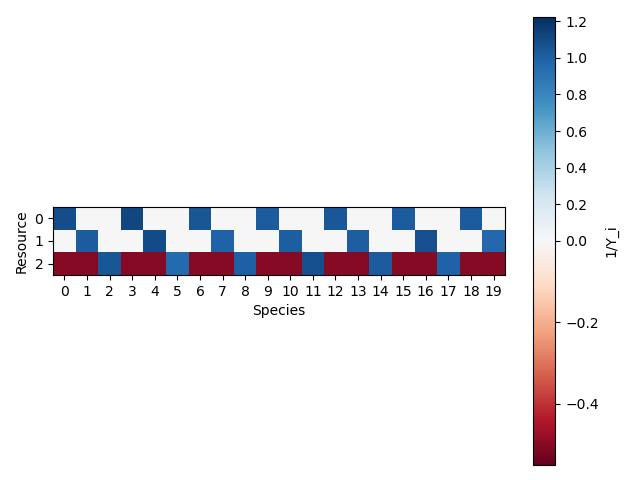

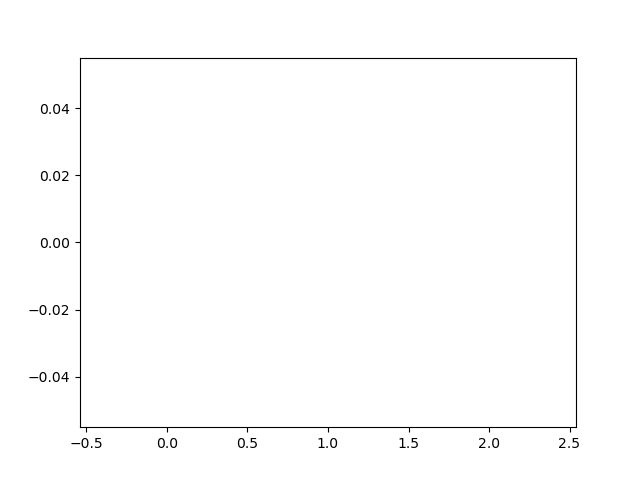

In [333]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots()
ax.bar(np.arange(N_resources),entry_rates)
plot_matrix(inv_yields,
            xticks = np.arange(N_species),x_ticklabels = np.arange(N_species),
            yticks = np.arange(N_resources), y_ticklabels = np.arange(N_resources),
           xlabel='Species',
           ylabel='Resource',
            cmap='RdBu',
           cbar_label = '1/Y_i')

plt.savefig('inv_yields.{}.png'.format(dataset_name),format='png',transparent=True)
plt.savefig('inv_yields.{}.pdf'.format(dataset_name),format='pdf',transparent=True)

In [334]:
which_option = 'A'

In [335]:
if which_option!='A': print('You did not select this option!'); 
else:  
    N_samples = 1000
    species_traces_full = []
    resource_traces_full = []
    initial_resource_abundances = np.zeros((N_samples,2)) #only 2 resources are supplied
    for sample in range(N_samples):
        if sample%50==0: print(sample)
        
        ''' Resource entries. Supplied resources are always the same, but their initial quantity is random. '''
        entry_rates = np.zeros(N_resources) #all noise is internal.
        entered_res = []
        
        species_abus = np.random.random(N_species)
        
        base_rate = 1-sample/N_samples #from 0 to 1
        resource_abus = np.zeros(3) 
        ''' Entry rate of resource 1 is highly fluctuating across samples: '''
        resource_abus[0] = 75+np.random.normal(0,res2_sigma)
        ''' Entry rate of resource 1 is highly fluctuating across samples: '''
        resource_abus[1] = 75+np.random.normal(0,30)
        ''' Entry rate of resource 2 is 0 '''
        resource_abus[2] = 0.0
        
        initial_resource_abundances[sample] = resource_abus[:2] #supplied total resource
    
        time0 = time.time()
    
    
        ''' Prepare noise ''' 
        entry_rate_sigma= 5
        sigma_outside = 1*entry_rate_sigma #Since we already set the noise in the previous lines.
        ###################################################### Make the noise on each resource different, so modes are well-decoupled in eigenvalues ###################
        sigma_inside = np.eye(3); sigma_inside[0,0] = 5; sigma_inside[1,1] = 5; sigma_inside[2,2] = 5
        #################################################################################################################################################
        outside_resource_noise_prev = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>1e-10) #noise for supplied resources is large
        inside_resource_noise_prev = np.random.normal([0]*3,sigma_inside)*np.sqrt(dt)*(entry_rates<1e-10) #noise for cross-fed resources is small
        tau = 0.000001 #autocorrelation time of the resource noise. Here it's made extremely small st noise is white.
    
        
        for step in range(1000):
            
            ''' Growth rates '''
            growth_rates,total_growth_rate_per_species = species_growth_rates(resource_abus,species_abus,
                         growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                        )
        
            
            
            d_res = d_resources(resource_abus,species_abus,
                       entry_rates,
                        total_growth_rate_per_species,
                       inv_yields)-resource_abus*dilution
            
            d_sp = d_species(species_abus,growth_rates)-species_abus*dilution#+1e-8
            
            species_abus += d_sp*dt +np.random.normal(0,0.5,
                                                      size=(N_species))*np.sqrt(dt)
    
            ''' Colored noise '''
            # outside_resource_noise = (np.exp(-dt/tau)*outside_resource_noise_prev
            #     +np.sqrt(1-np.exp(-2*dt/tau))*np.random.normal(0,sigma_outside,size=(N_resources)))*np.sqrt(dt)*(entry_rates>0) #noise for supplied resources
            # inside_resource_noise = (np.exp(-dt/tau)*inside_resource_noise_prev
            #     +np.sqrt(1-np.exp(-2*dt/tau))*np.random.normal(0,sigma_inside,size=(N_resources)))*np.sqrt(dt)*(entry_rates<1e-10) #noise for cross-fed resources
            ''' White noise '''
            outside_resource_noise = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>1e-10) #noise for supplied resources
            inside_resource_noise = np.diagonal(np.random.normal([0]*3,sigma_inside)*np.sqrt(dt))*(entry_rates<1e-10)#noise for cross-fed resources
            
            ''' Have noise only for present resources '''
            outside_resource_noise[resource_abus<1e-10] = 0
            inside_resource_noise[resource_abus<1e-10] = 0
            
            resource_abus += d_res*dt+outside_resource_noise+inside_resource_noise
            resource_abus[resource_abus<1e-10] = 0
            species_abus[species_abus<1e-10] = 0
    
            outside_resource_noise_prev = outside_resource_noise
            inside_resource_noise_prev = inside_resource_noise
            
        #Append abundances to data
        species_traces_full.append(np.copy(species_abus))
        resource_traces_full.append(np.copy(resource_abus))
        
    
    inv_yields_complete = np.copy(inv_yields)
    growth_choices_complete = np.copy(growth_choices)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


In [336]:
resource_traces_full = np.array(resource_traces_full)
species_traces_full = np.array(species_traces_full)

Text(0, 0.5, 'n')

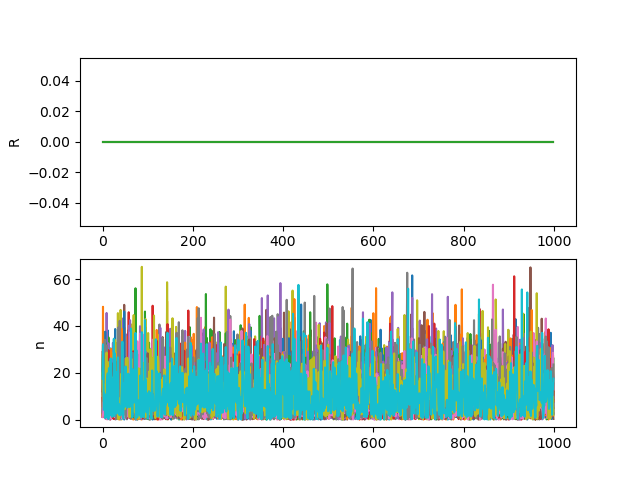

In [337]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[1].plot(species_traces_full)
ax[1].set_ylabel('n')
# ax[1].set_yscale('log')
# ax[0].set_yscale('log')

In [338]:
with open('{}/initial_resource_abundances.{}.dat'.format(dataset_name,dataset_name),'wb') as f:
    pickle.dump(initial_resource_abundances,f)
    f.close()

with open('{}/inv_yields_complete.{}.dat'.format(dataset_name,dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('{}/growth_choices_complete.{}.dat'.format(dataset_name,dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

with open('{}/species_traces_full.{}.dat'.format(dataset_name,dataset_name),'wb') as f:
    pickle.dump(species_traces_full,f)
    f.close()
with open('{}/resource_traces_full.{}.dat'.format(dataset_name,dataset_name),'wb') as f:
    pickle.dump(resource_traces_full,f)
    f.close()

In [339]:
species_traces = np.copy(species_traces_full)

# Data Analysis

Load pre-saved data for analysis.

In [9]:
with open('{}/initial_resource_abundances.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    initial_resource_abundances = pickle.load(f)
    f.close()

with open('{}/inv_yields_complete.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    inv_yields = pickle.load(f)
    f.close()
with open('{}/growth_choices_complete.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    growth_choices_complete = pickle.load(f)
    f.close()

with open('{}/species_traces_full.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    species_traces_full = pickle.load(f)
    species_traces = np.copy(species_traces_full)
    f.close()
    N_samples,N_species = np.shape(species_traces_full)
    print(N_samples,N_species)
with open('{}/resource_traces_full.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    resource_traces_full = pickle.load(f)
    f.close()

1000 20


In [10]:
''' Make the dataset in relative abundances to get the distorted version of the lowvar dataset '''
relative_abundances_bool = False
if relative_abundances_bool:
    data = species_traces/np.sum(species_traces,axis=1)[:,None] #Relative Abundance Data
    out_dir = dataset_name+'.relative_abundances'
    if os.path.exists(out_dir)==False:
        os.mkdir(out_dir)
    dataset_name = out_dir
else:
    data  = species_traces #Absolute abundance data
# data = data[-2000:,means>0.002]
means = np.mean(data,axis=0)
vars = np.var(data,axis=0)
N_species = np.shape(data)[1]

In [11]:
sample_abus = np.sum(data,axis=1)
N_mean = np.mean(sample_abus)
sigma_N  = np.std(sample_abus)

print('Total sample abundances: {:.3f}+-{:.3f}'.format(N_mean,sigma_N))

Total sample abundances: 232.426+-48.346


1.5865584895753477


Text(0, 0.5, 'P(rescaled_log_abundance)')

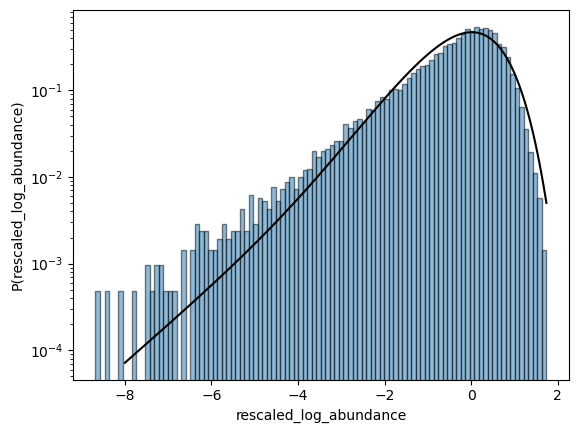

In [12]:
''' Check Gamma Distributions '''
from scipy.stats import gamma

rescaled_abundances = data/np.mean(data,axis=0)[None,:]

gamma_params = gamma.fit(rescaled_abundances[rescaled_abundances>0].flatten(),5)
gamma_func = gamma(a=gamma_params[0],loc=gamma_params[1],scale=gamma_params[2])


# gamma_func.fit(rescaled_abundances.flatten())


log_rescaled_abundances = np.log(rescaled_abundances[rescaled_abundances>0])

counts,bins = np.histogram(log_rescaled_abundances.flatten(),bins=100,
                          density=True)
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

fig,ax = plt.subplots()
ax.bar(bin_centers,
       counts,
       width= dbin,
       alpha=0.5,edgecolor='k')
x_vect = np.linspace(max(np.min(rescaled_abundances),np.exp(-8)),np.max(rescaled_abundances),10000)
print(gamma_params[0])
gamma_pdf = gamma_func.pdf(x_vect)

ax.plot(np.log(x_vect),gamma_pdf*x_vect,'k')
ax.set_yscale('log')
ax.set_xlabel('rescaled_log_abundance')
ax.set_ylabel('P(rescaled_log_abundance)')
# plt.savefig('Gamma_distribution.{}.png'.format(dataset_name),format='png',transparent=True)
# plt.savefig('Gamma_distribution.{}.pdf'.format(dataset_name),format='pdf',transparent=True)

In [13]:
with open('full_dataset.filtered.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(data,f)
    f.close()

In [14]:

cov_matrix = np.corrcoef(data.T)

true_eigvals,true_eigvects = np.linalg.eigh(cov_matrix)

argsorted_true_eigvals = np.argsort(true_eigvals)
true_eigvals=true_eigvals[argsorted_true_eigvals]
true_eigvects = true_eigvects[:,argsorted_true_eigvals]



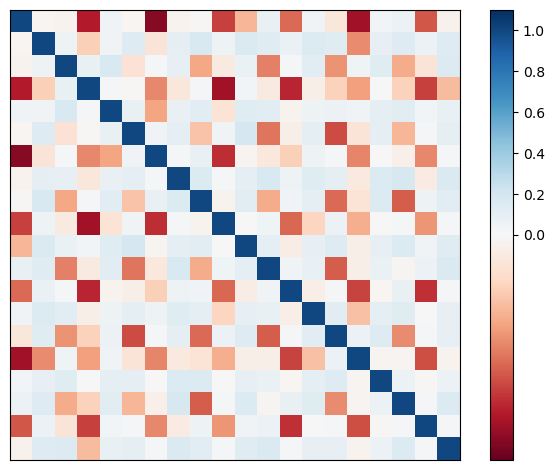

In [15]:
plot_matrix(cov_matrix,
           # cmap='Blues'
           )

In [16]:
N_randomizations = 100
dummy_eigvals = []
dummy_eigvects = []
full_dummy_dataset = []
for kk in range(N_randomizations):
        
    dummy_subset = np.copy(data)
    shuffled_comms = np.arange(np.shape(data)[0])
    shuffled_species = np.arange(np.shape(data)[1])
    for s in range(N_species):
        ''' Shuffle Abundances of one species across samples '''
        np.random.shuffle(shuffled_comms) #shuffled community indices
        dummy_subset[:,s] = dummy_subset[shuffled_comms,s]
    # for c in range(np.shape(data)[0]):
    #     ''' Shuffle abundnaces of species within each sample, which should keep the large fluctuations in a sample '''
    #     np.random.shuffle(shuffled_species)
    #     dummy_subset[c,:] = dummy_subset[c,shuffled_species]

    for comm in dummy_subset:
        full_dummy_dataset.append(comm)
    print('{}, with shape ({},{})'.format(kk,np.shape(dummy_subset)[0],np.shape(dummy_subset)[1]))
    
    cov_dummy = np.corrcoef(dummy_subset.T)

    eigvals,eigvects = np.linalg.eigh(cov_dummy)

    for eigval in eigvals: dummy_eigvals.append(eigval)
    for eigvect in eigvects.T: dummy_eigvects.append(eigvect)

0, with shape (1000,20)
1, with shape (1000,20)
2, with shape (1000,20)
3, with shape (1000,20)
4, with shape (1000,20)
5, with shape (1000,20)
6, with shape (1000,20)
7, with shape (1000,20)
8, with shape (1000,20)
9, with shape (1000,20)
10, with shape (1000,20)
11, with shape (1000,20)
12, with shape (1000,20)
13, with shape (1000,20)
14, with shape (1000,20)
15, with shape (1000,20)
16, with shape (1000,20)
17, with shape (1000,20)
18, with shape (1000,20)
19, with shape (1000,20)
20, with shape (1000,20)
21, with shape (1000,20)
22, with shape (1000,20)
23, with shape (1000,20)
24, with shape (1000,20)
25, with shape (1000,20)
26, with shape (1000,20)
27, with shape (1000,20)
28, with shape (1000,20)
29, with shape (1000,20)
30, with shape (1000,20)
31, with shape (1000,20)
32, with shape (1000,20)
33, with shape (1000,20)
34, with shape (1000,20)
35, with shape (1000,20)
36, with shape (1000,20)
37, with shape (1000,20)
38, with shape (1000,20)
39, with shape (1000,20)
40, with s

In [17]:
with open('dummy_data.MCMC.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(np.array(full_dummy_dataset),f)
    f.close()

0.02
lambda_min = 0.7371572875253811
2 2 16


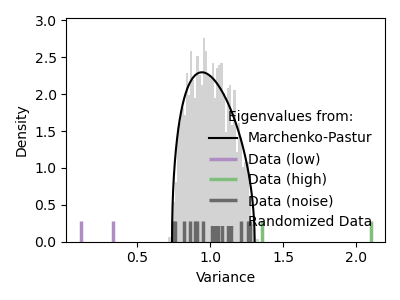

In [18]:
counts,bins = np.histogram(dummy_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(dummy_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2


'''
Draw the Marchenko-Pastur distribution
'''
lam = np.shape(data)[1]/np.shape(data)[0]
print(lam)
var=1.0 #as long as we consider data normalized by 1/std(x), such that we have a correlation matrix.
marchenko_pastur_min,marchenko_pastur_max = Marchenko_Pastur_significance_threshold(lam,var)
eig_x_vector,marchenko_pastur_distr = Marchenko_Pastur_distribution(marchenko_pastur_min,marchenko_pastur_max,lam,var)
print('lambda_min = {}'.format(marchenko_pastur_min))

%matplotlib widget
fig,ax = plt.subplots(figsize=(4,3))
counts,bins = np.histogram(dummy_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(dummy_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

ax.bar(bin_centers[:],counts[:],
       width=dbin*1.02,edgecolor=None,
       color = 'lightgray',
       zorder=0,
      label='Randomized Data')
ax.plot(eig_x_vector,marchenko_pastur_distr,'k',label='Marchenko-Pastur')
''' Plot the eigenvalues from the dataset '''
low_eigvals = true_eigvals[true_eigvals<marchenko_pastur_min]; true_lowvar_eigvects = true_eigvects[:,true_eigvals<marchenko_pastur_min]
if np.shape(data)[0]<np.shape(data)[1]: #less samples than species
    true_lowvar_eigvects = true_lowvar_eigvects[:,low_eigvals>1e-10] #keep nonzero eigenvalues
    low_eigvals = low_eigvals[low_eigvals>1e-10]
high_eigvals = true_eigvals[true_eigvals>marchenko_pastur_max]; true_highvar_eigvects = true_eigvects[:,true_eigvals>marchenko_pastur_max]
noise_eigvals = true_eigvals[(marchenko_pastur_min<= true_eigvals) & (true_eigvals <= marchenko_pastur_max)]
ax.vlines(low_eigvals,0,0.1*np.max(counts[1:]),
          colors=[175/255,141/255,195/255],#'tab:red',
          linewidth=2.5,zorder=0,
         label='Data (low)')
ax.vlines(high_eigvals,0,0.1*np.max(counts[1:]),
          colors=[127/255,191/255,123/255],#'tab:green',
          linewidth=2.5,zorder=0,
         label='Data (high)')
ax.vlines(noise_eigvals,0,0.1*np.max(counts[1:]),
          colors='dimgray',#'tab:orange',
          linewidth=2.5,zorder=0,
         label='Data (noise)')

ax.legend(loc='best',frameon=False,
          title='Eigenvalues from:')
ax.set_xlabel('Variance')
ax.set_ylabel('Density')
ax.set_ylim(bottom=0,top=np.max(counts[1:])*1.1)
# ax.set_xscale('log'); ax.set_xlim(left=0.9*np.min(low_eigvals[low_eigvals>0]))
plt.tight_layout()

plt.savefig('eigenvalue_distribution.{}.png'.format(dataset_name),format='png',transparent=True)
plt.savefig('eigenvalue_distribution.{}.svg'.format(dataset_name),format='svg',transparent=True)
print(len(low_eigvals),len(high_eigvals),len(noise_eigvals))

In [19]:
species_sorting = [0,3,6,9,12,15,18,1,4,7,10,13,16,19,2,5,8,11,14,17] #for the 3-group dataset
# species_sorting = [0,2,4,6,8,10,12,14,16,18,1,3,5,7,9,11,13,15,17,19]
data_sp_sorted = data[:,species_sorting]

[  0  20  40  61  81 101 122 142 163 183 203 224 244 265 285 305 326 346
 366 387 407 428 448 468 489 509 530 550 570 591 611 632 652 672 693 713
 733 754 774 795 815 835 856 876 897 917 937 958 978 999]


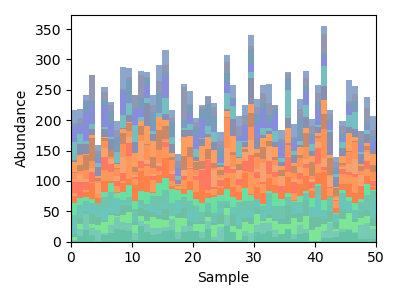

In [20]:
import matplotlib as mpl

cmap = plt.get_cmap('Set2')
N_colors = len(cmap.colors)
N_sampl_to_plot = 50
samples_to_plot = np.linspace(0,N_samples-1,N_sampl_to_plot,dtype=int)
print(samples_to_plot)
fig,ax = plt.subplots(figsize=(4,3))
ax.bar(np.arange(N_sampl_to_plot)+0.5,
       data_sp_sorted[samples_to_plot,0],
      width=1,
      color=cmap(0))
cumsummed_data = np.cumsum(data_sp_sorted,axis=1)
np.random.seed(0)
for s in range(1,N_species):
# for s in :
    # color = cmap(s%N_colors) #from discrete map
    color_index = s//7
    color = np.array(cmap(color_index))
    color[:3] *= 1+np.random.normal(0,0.1,size=3)
    color[color>1] = 1.0
    ax.bar(np.arange(N_sampl_to_plot)+0.5,
           data_sp_sorted[samples_to_plot,s],
           bottom = cumsummed_data[samples_to_plot,s-1],
           width=1,
          color=color)
ax.set_xlabel('Sample')
if relative_abundances_bool:
    ax.set_ylabel('Composition')
else:
    ax.set_ylabel('Abundance')
ax.set_xlim(left=0,right=N_sampl_to_plot)
plt.tight_layout()
format='png'
plt.savefig('{}_CR_batch_culture_composition.{}'.format(dataset_name,format),transparent=True,dpi=300)
format='svg'
plt.savefig('{}_CR_batch_culture_composition.{}'.format(dataset_name,format),transparent=True,dpi=300)

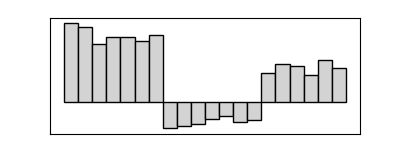

In [22]:
''' Plot low-variance eigenvector '''
mode = 1
fig,ax = plt.subplots(figsize=(4,1.5))
ax.bar(np.arange(N_species),
       true_eigvects[species_sorting,mode],
       edgecolor='k',facecolor='lightgray',
       width=1)
# ax.set_xlabel('Species')
# ax.set_xticks(np.arange(0,N_species+1,5,dtype=int))
ax.set_xticks([])
ax.set_yticks([])
# plt.tight_layout()
format='svg'
plt.savefig('eigenmode.{}.{}.{}'.format(dataset_name,mode,format),transparent=True,format=format)

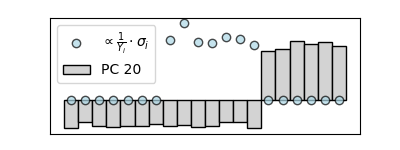

In [326]:
''' Plot low-variance eigenvector and inverse yields vector, properly rescaled '''
data_std = np.std(data,axis=0)

# Rescaled inv_yields by species standard deviation
rescaled_inv_yields = inv_yields[1,species_sorting]*data_std

# Make rescaled inv_yields a unitary vector
rescaled_inv_yields /= np.sqrt(np.sum(rescaled_inv_yields**2))


fig,ax = plt.subplots(figsize=(4,1.5))
ax.bar(np.arange(N_species),
       true_lowvar_eigvects[species_sorting,0], #if needed, multiply by a negative sign to match sign criterion
       edgecolor='k',facecolor='lightgray',
       width=1,label='PC 20')
# ax.bar(np.arange(N_species),
#        rescaled_inv_yields,alpha=0.5,
#        edgecolor='k',facecolor='lightblue',
#        width=1,
#        # label='True'
#        label=r'$\propto \frac{1}{Y_i} \cdot \sigma_i$'
#       )
ax.scatter(np.arange(N_species),
       rescaled_inv_yields,alpha=0.7,zorder=2,
       edgecolor='k',color='lightblue',
       # width=1,
       # label='True'
       label=r'$\propto \frac{1}{Y_i} \cdot \sigma_i$'
      )
plt.legend()
# ax.set_xlabel('Species')
# ax.set_xticks(np.arange(0,N_species+1,5,dtype=int))
# ax.set_ylabel('Rescaled \n Inverse Yield')
# ax.set_ylabel(r'$1/Y_i^3 \cdot \sigma_i$')
ax.set_xticks([])
ax.set_yticks([])
# plt.tight_layout()
format='svg'
plt.savefig('low_variance_eigenmode.vs_true.{}.{}'.format(dataset_name,format),transparent=True,format=format)